# Import Required Libraries

In [1]:
import sys

sys.path.insert(0, "../../src")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython import display

from bss.PredictiveDecorrBSS import PredictiveDecorrBSS
from bss.bss_utils import addWGN
from python_utils.visualization_utils import display_matrix, subplot_1D_signals
from python_utils.python_utils import Timer

import warnings

warnings.filterwarnings("ignore")

notebook_name = "4PAM"


# 4-PAM symbol utilities (small helpers, not present in this repo's utils)
def map_estimates_to_symbols(Y, symbols):
    """Map each element of Y to the closest symbol in the alphabet."""
    Ysymbols = np.zeros_like(Y)
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            idx = np.argmin(np.abs(Y[i, j] - symbols))
            Ysymbols[i, j] = symbols[idx]
    return Ysymbols


def SER(S, Y):
    """Symbol Error Rate between ground-truth symbols S and predicted symbols Y."""
    return np.sum((S - Y) != 0) / (S.size)

In [2]:
# Fixed seed with a well-conditioned mixing matrix (reproducible >= 25 dB per source)
seed_ = 10
print(seed_)
np.random.seed(seed_)

10


# Source Generation and Mixing Scenario

In [3]:
N = 100000
NumberofSources = 3
NumberofMixtures = 4
S = (2 * (np.random.randint(0, 4, (NumberofSources, N))) - 3).astype(np.float64)
A = np.random.standard_normal(size=(NumberofMixtures, NumberofSources))
X = A @ S
print("Condition Number of Mixing Matrix is {}".format(np.linalg.cond(A)))
SNRlevel = 30
Xclean = X.copy()
X = addWGN(X, SNRlevel)
NoisePart = X - Xclean

SNRinp = 10 * np.log10(
    np.sum(np.mean((X - NoisePart) ** 2, axis=1))
    / np.sum(np.mean(NoisePart**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))

Condition Number of Mixing Matrix is 4.378686644542587
The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.993675036015524


# Visualize Generated Sources and Mixtures

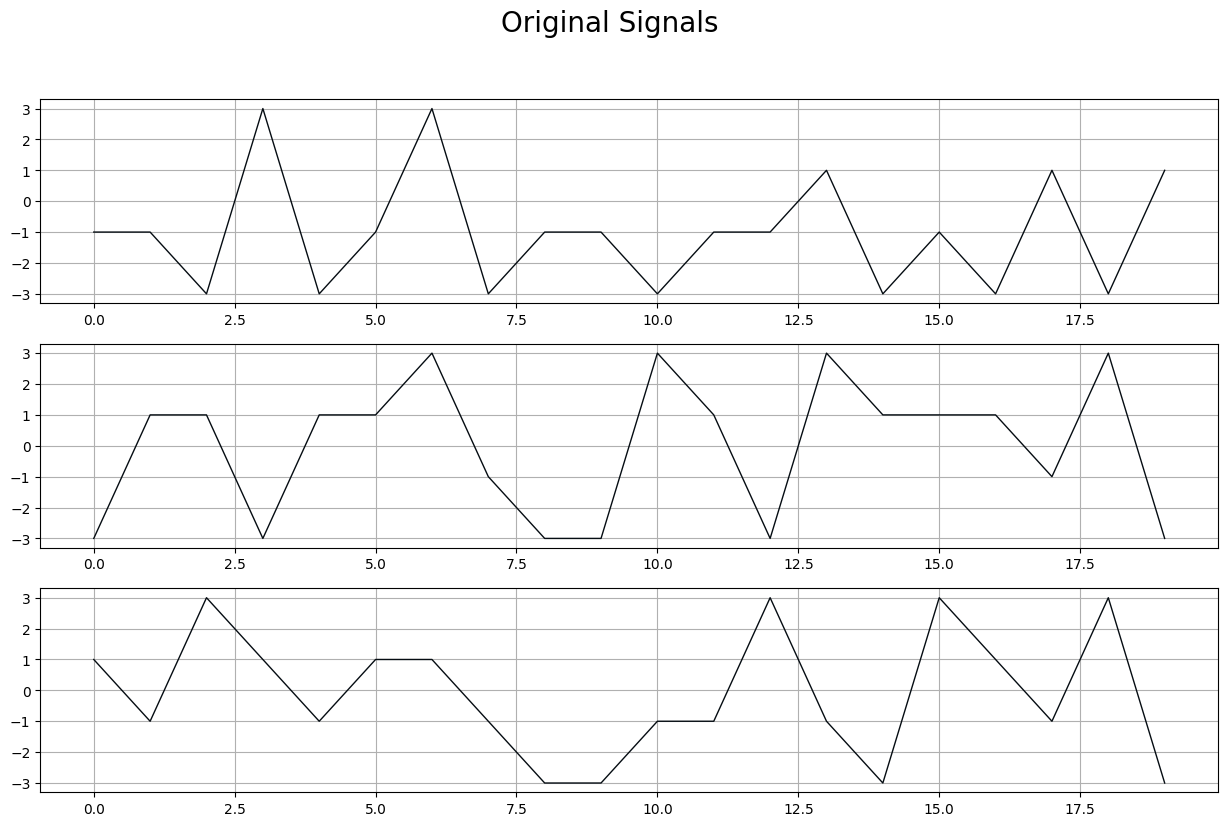

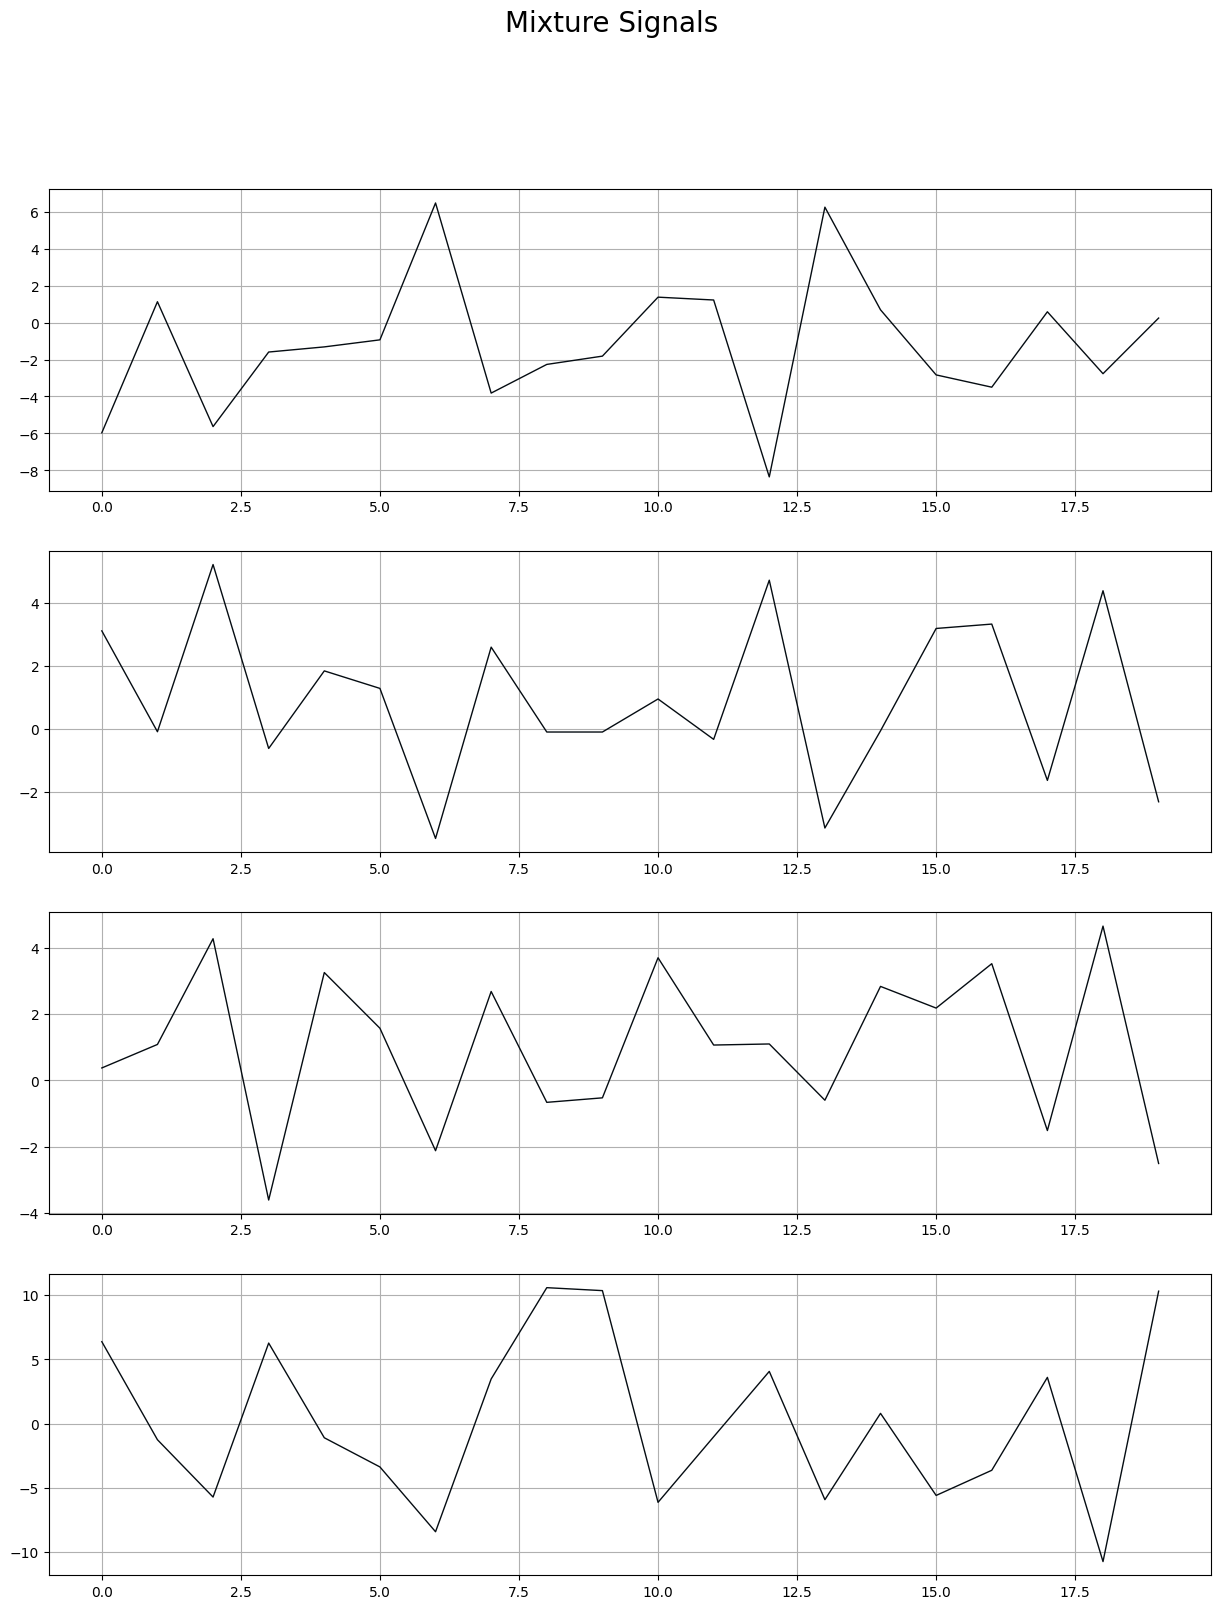

In [4]:
subplot_1D_signals(
    S[:, 0:20], title="Original Signals", figsize=(15.2, 9)
)
subplot_1D_signals(
    X[:, 0:20], title="Mixture Signals", figsize=(15, 18)
)

# Algorithm Hyperparameter Selection and Weight Initialization

In [5]:
s_dim = S.shape[0]
x_dim = X.shape[0]

debug_iteration_point = 25000
model = PredictiveDecorrBSS(
    n_sources=s_dim,
    presumed_domain="antisparse",
    lambda_lateral=0.99,
    gamma_predictive=250,
    lr_W=3 * 1e-2,
    lr_W_rule="constant",
    neural_lr_start=0.5,
    neural_lr_stop=1e-6,
    neural_dynamics_iterations=400,
    neural_lr_rule="divide_by_loop_index",
    neural_lr_decay_divider=200,
    neural_OUTPUT_COMP_TOL=1e-7,
    Sgt=S,
    debug_iteration_point=debug_iteration_point,
    plot_debug_during_training=True,
)

# Run Predictive Entropy Maximization Algorithm on Mixture Signals

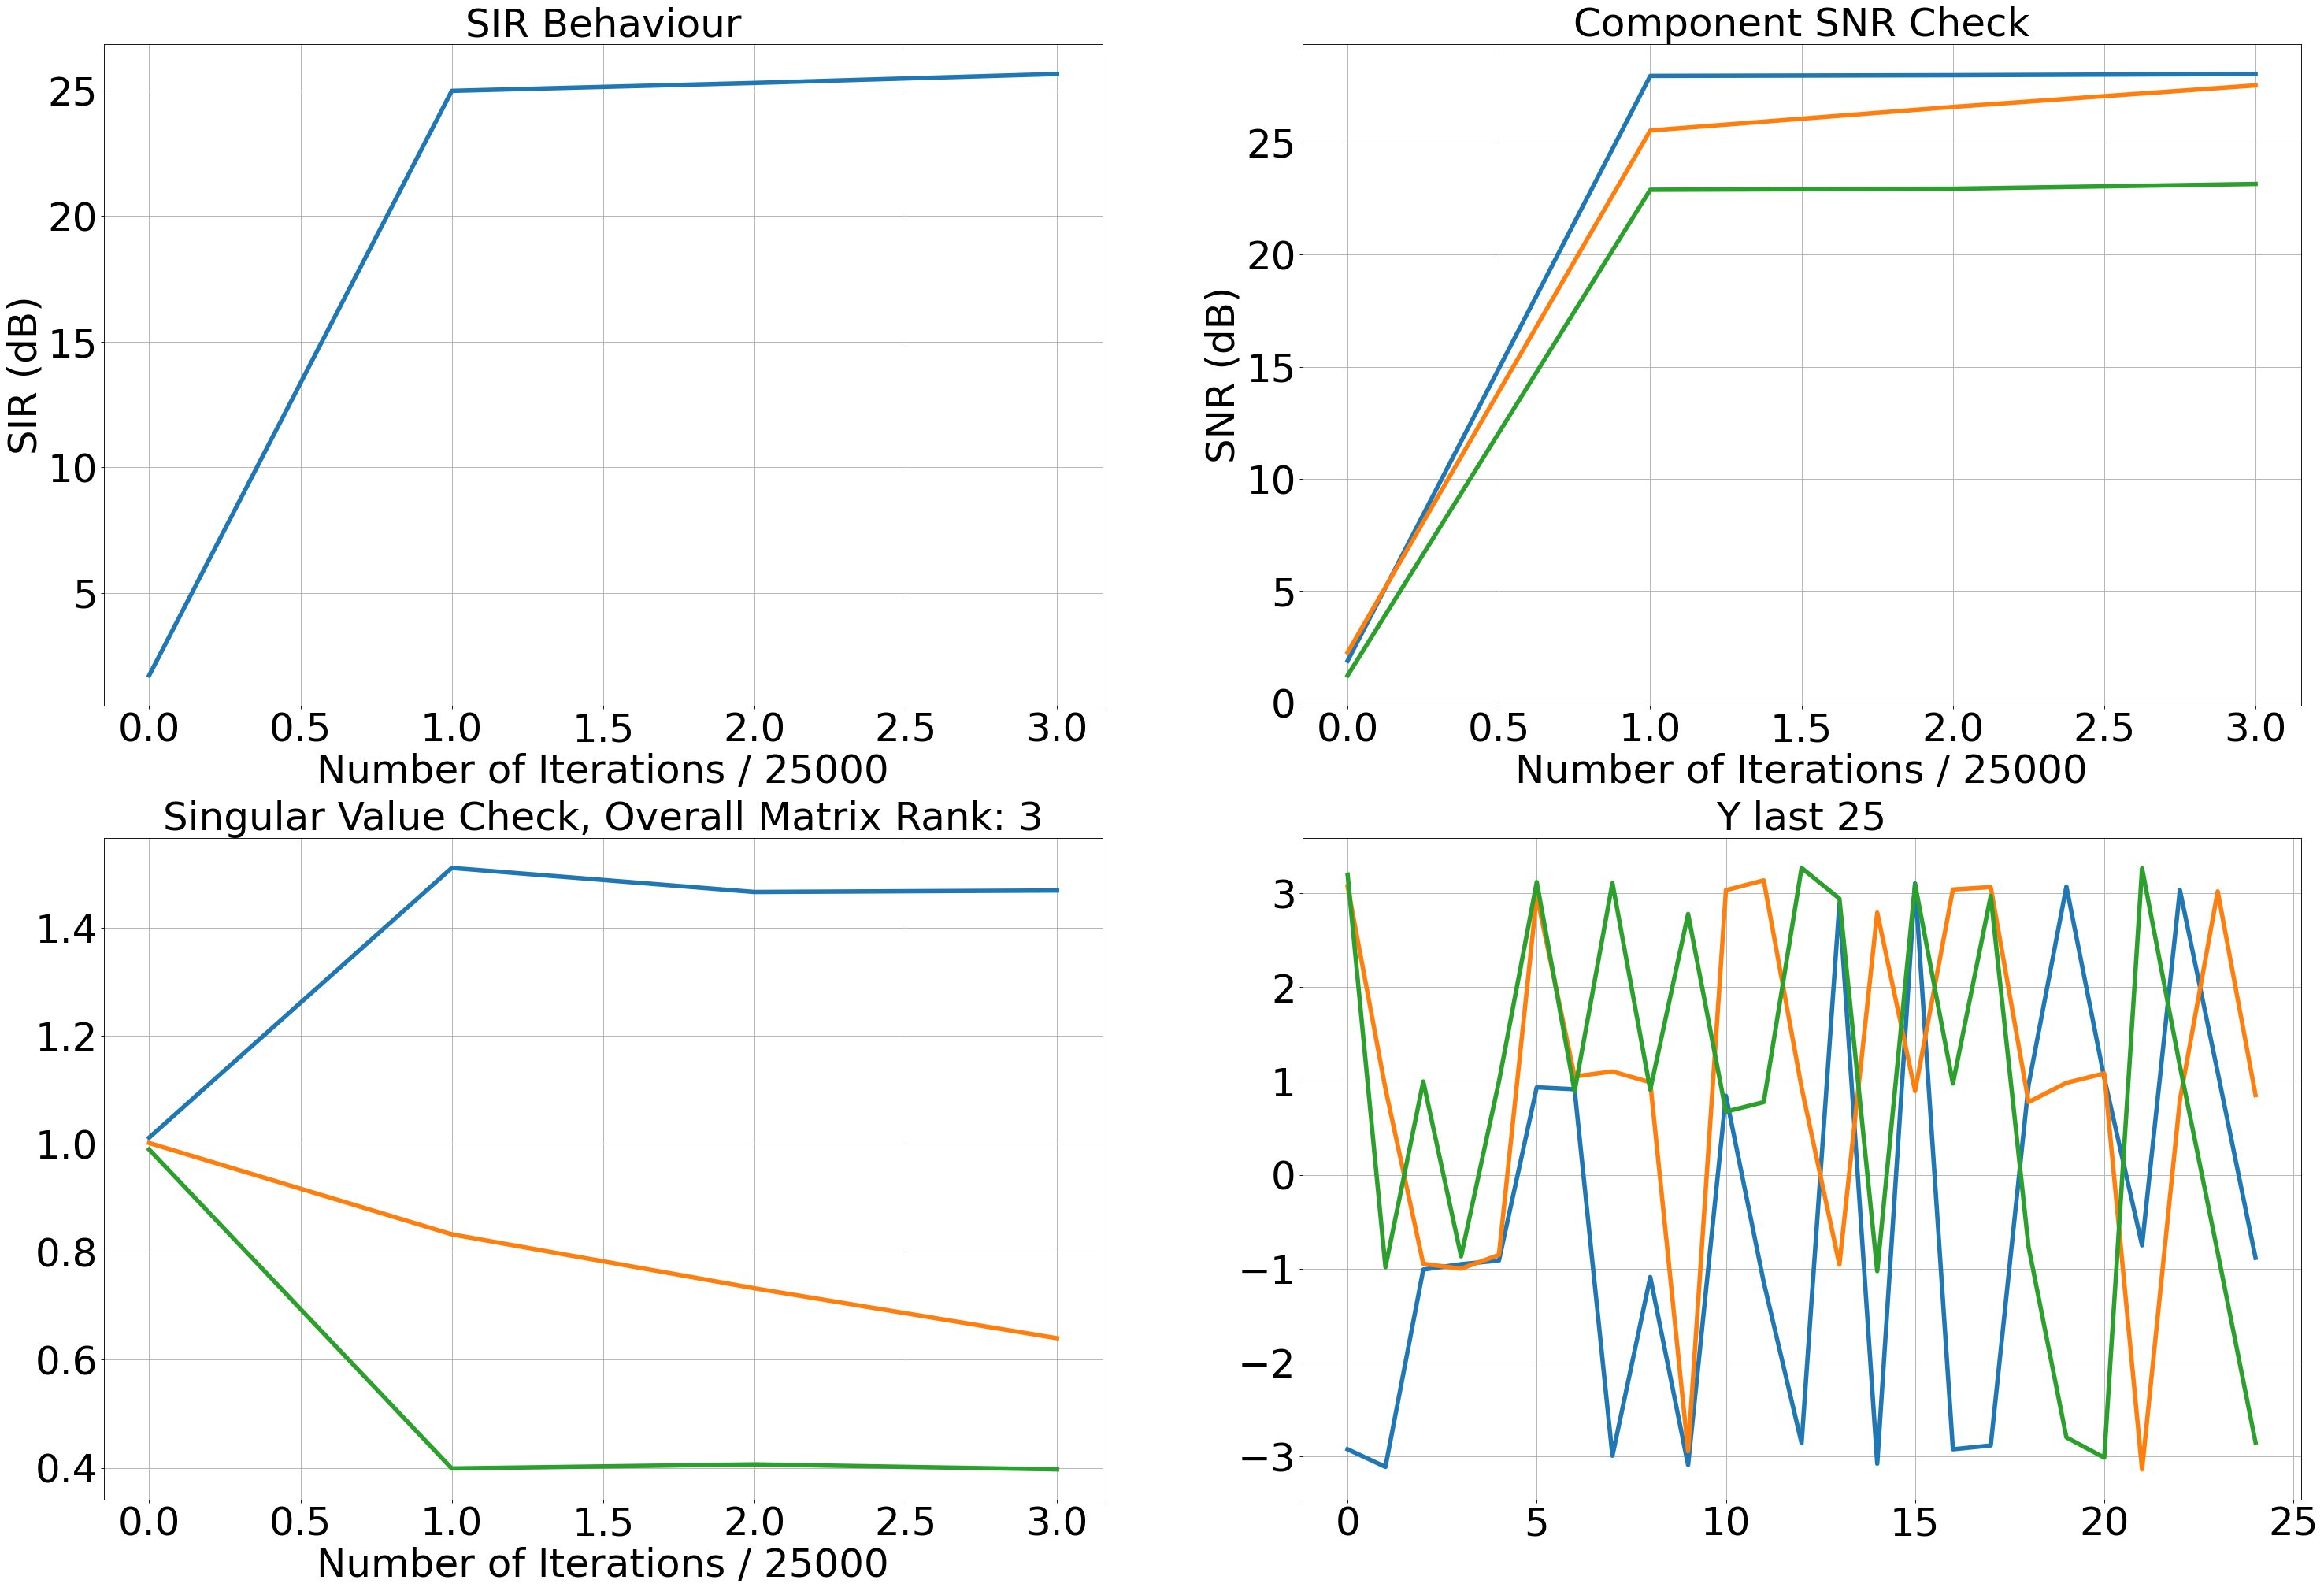

100%|████████████████████████████████| 100000/100000 [00:08<00:00, 11927.02it/s]


Algorithm took 8.403287 sec.


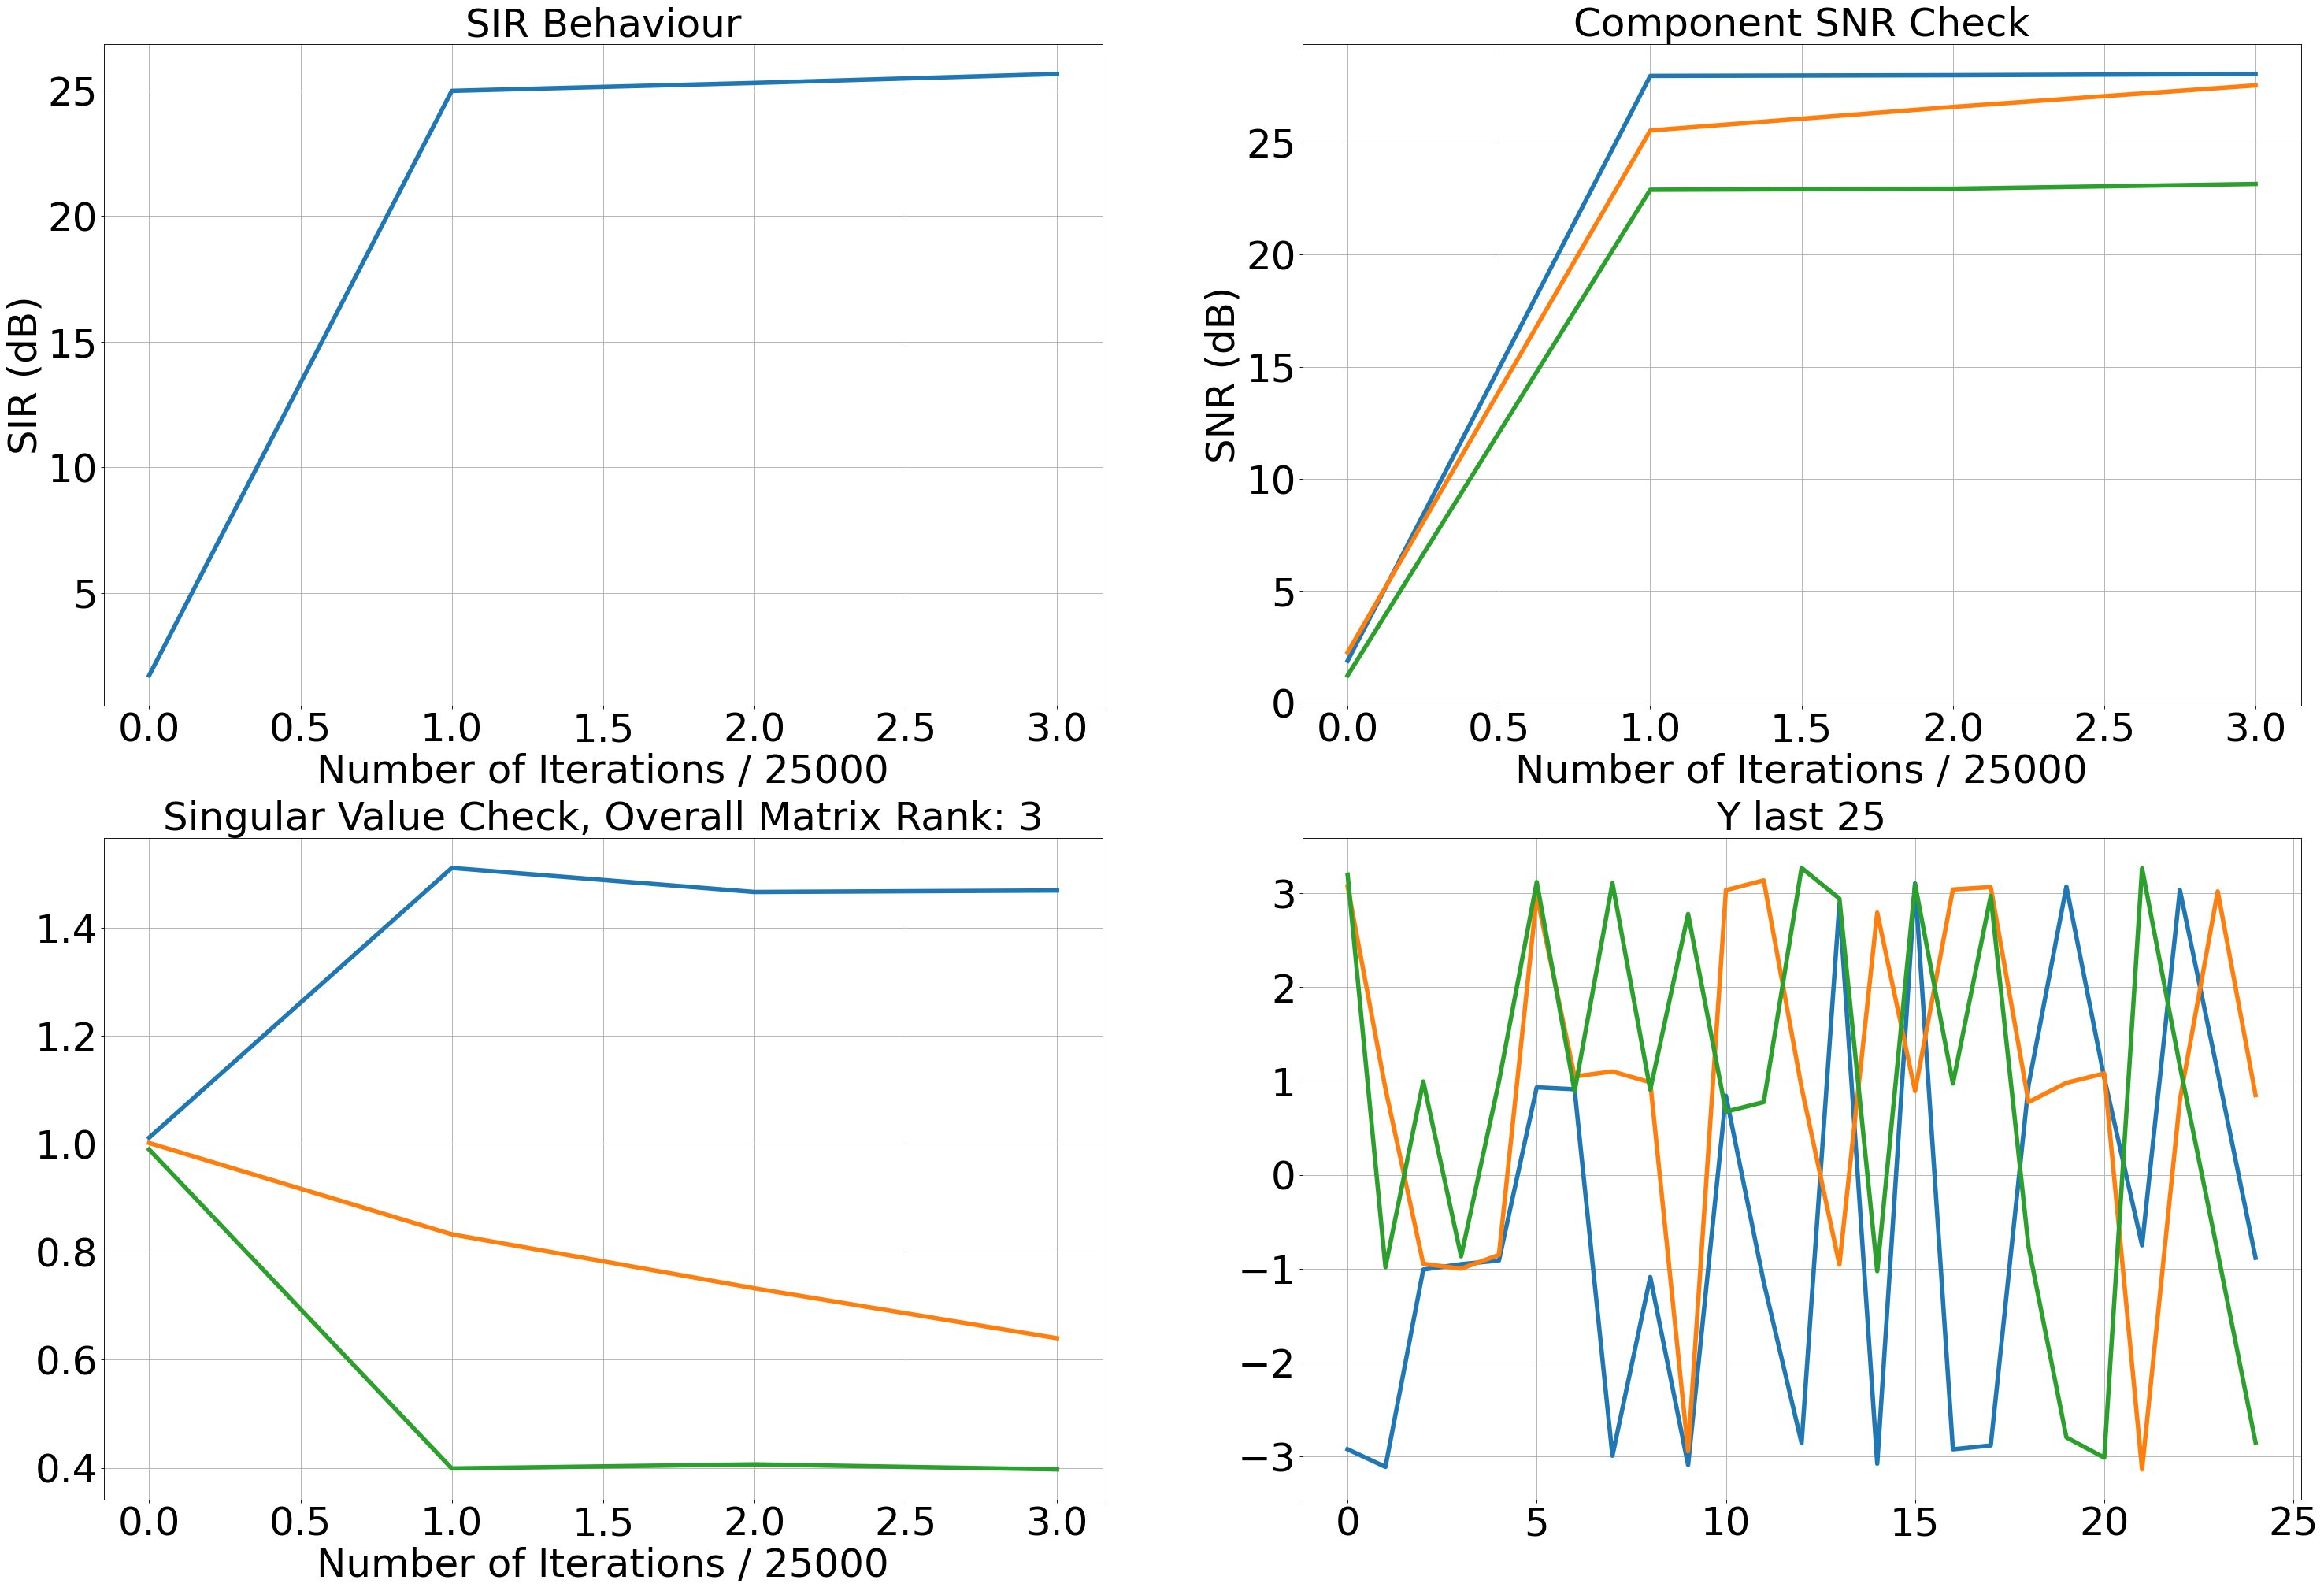

In [6]:
with Timer() as t:
    model.fit(
        X / 3,
        n_epochs=1,
        shuffle_samples=True,
    )
print("Algorithm took %f sec." % (t.interval))

# Visualize SINR Convergence

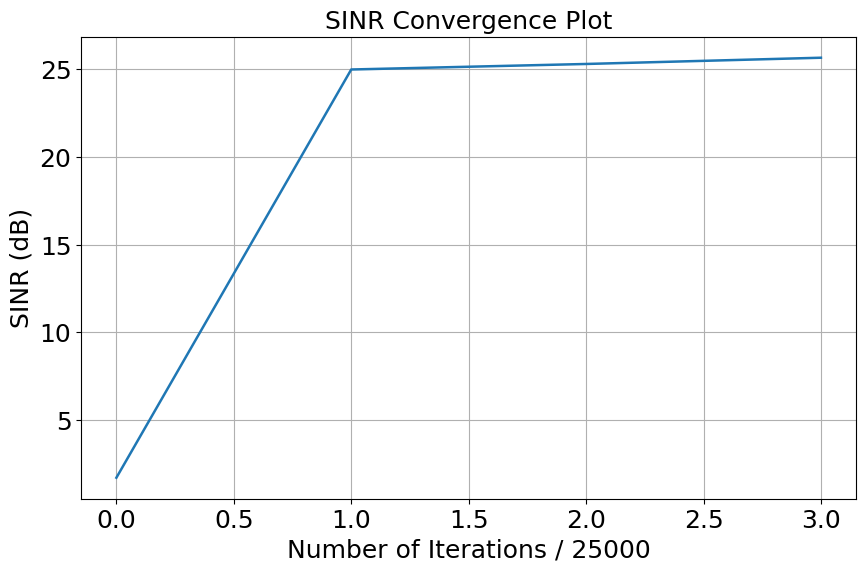

Final SINR: 25.659376737674688


In [7]:
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
plt.figure(figsize=(10, 6))
plt.plot(np.array(model.SINR_history), linewidth=1.8)
plt.xlabel("Number of Iterations / {}".format(debug_iteration_point), fontsize=18)
plt.ylabel("SINR (dB)", fontsize=18)
plt.title("SINR Convergence Plot", fontsize=18)
plt.grid()
plt.show()

print("Final SINR: {}".format(np.array(model.SINR_history[-1])))

# Calculate Resulting Component SNRs and Overall SINR

In [8]:
Wf = model.W
Y = Wf @ X
Y_ = model.signed_and_permutation_corrected_sources(S, Y)
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
Y_ = coef_ * Y_

print("Component SNR Values : {}\n".format(model.ComputeSNR(S, Y_)))

SINR = model.ComputeSINR(S, Y_)

print("Overall SINR : {}".format(SINR))

Component SNR Values : [27.85280653 28.40825154 23.83752465]

Overall SINR : 26.189850540297197


# Vizualize Extracted Signals Compared to Original Sources

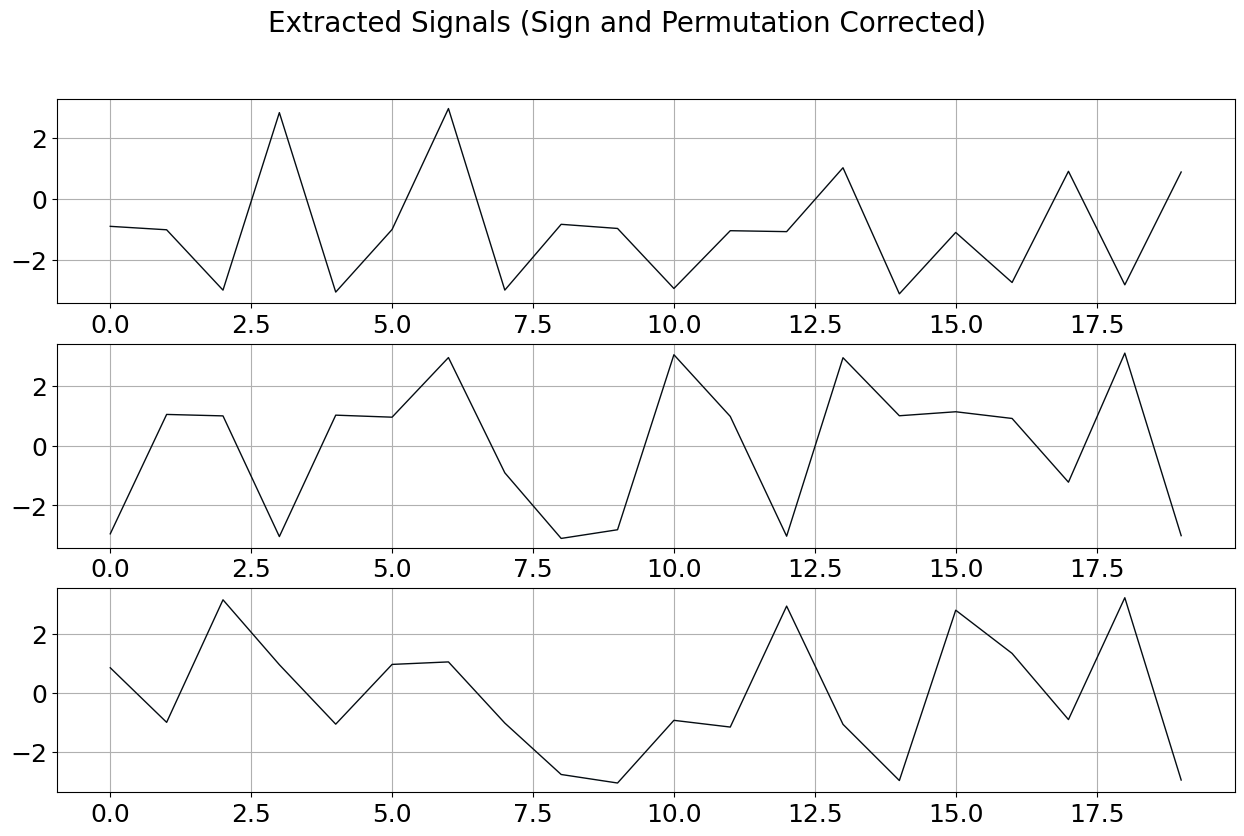

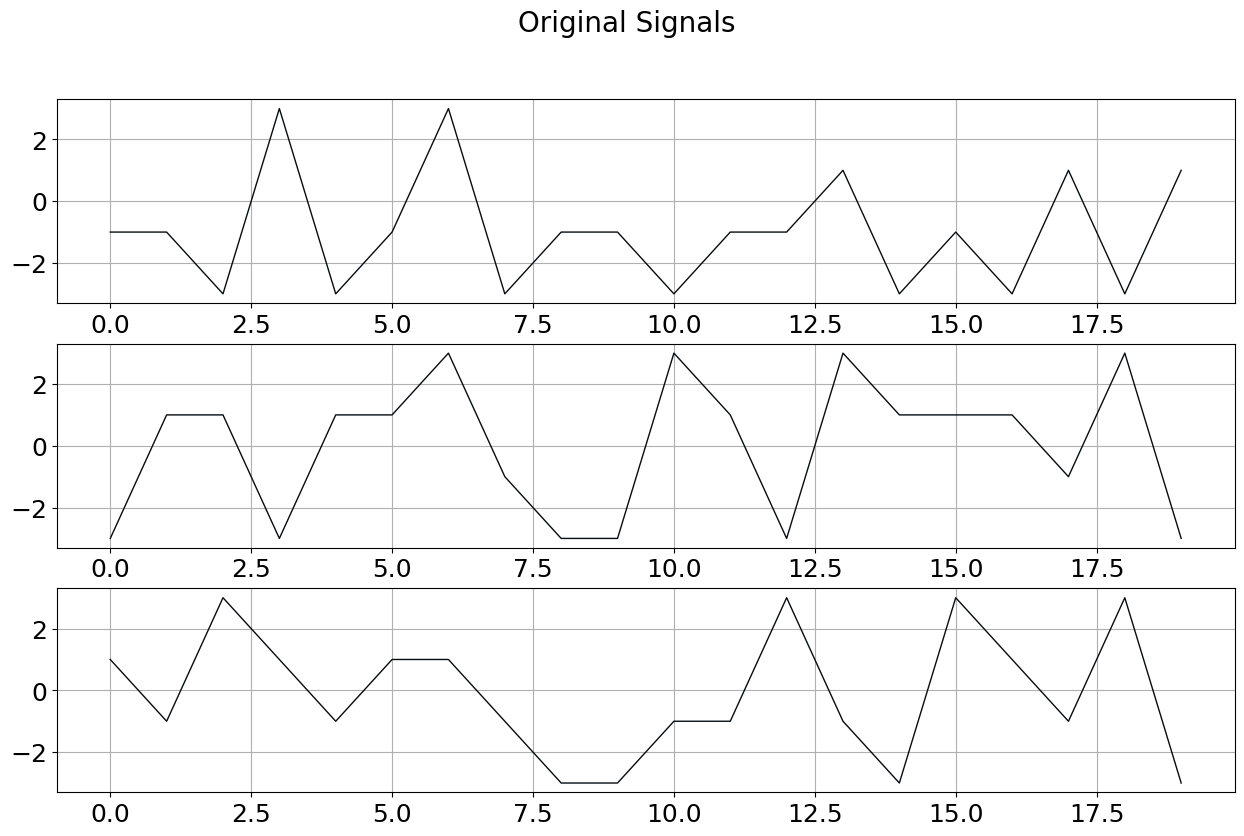

In [9]:
subplot_1D_signals(
    Y_[:, 0:20],
    title="Extracted Signals (Sign and Permutation Corrected)",
    figsize=(15.2, 9),
)
subplot_1D_signals(
    S[:, 0:20], title="Original Signals", figsize=(15.2, 9)
)

# Measure Symbol Error Rate

In [10]:
Wf = model.W
Y = Wf @ X
Y_ = model.signed_and_permutation_corrected_sources(S, Y)
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
Y_ = coef_ * Y_
Y_pred = map_estimates_to_symbols(Y_, np.array([-3, -1, 1, 3]))
print("Symbol Error Rate : {}".format(SER(S, Y_pred)))

Symbol Error Rate : 0.0
